## Importar Bibliotecas

In [45]:
# Bibliotecas generales
import librosa
import kagglehub
import shutil
import joblib
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Bibliotecas de Scikit Learn
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, ConfusionMatrixDisplay, confusion_matrix

## Obtener dataset de GTZAN de Kaggle

In [2]:
path = kagglehub.dataset_download("andradaolteanu/gtzan-dataset-music-genre-classification")

print("Copiando datos en Colab")
shutil.copytree(path, "/content/gtzan-dataset", dirs_exist_ok=True)

# Manualmente se agregó la categoría electronica que no viene en este dataset.
# Se hizo una carpeta llamada electronica dentro de /content/gtzan-dataset/Data/genres_original
# Se agregaron canciones en esa carpeta de electronica /content/gtzan-dataset/Data/genres_original/electronica

Using Colab cache for faster access to the 'gtzan-dataset-music-genre-classification' dataset.
Copiando datos en Colab


'/content/gtzan-dataset'

## Función para extraer características de audio

In [ ]:
DURACION_BLOQUE = 3
DURACION_TOTAL = 30
NUM_BLOQUES = DURACION_TOTAL // DURACION_BLOQUE

def extraer_caracteristicas(y_block, sr):
  """Extrae caracterIsticas de un fragmento de audio ya segmentado en memoria"""

  mfcc = librosa.feature.mfcc(y=y_block, sr=sr, n_mfcc=20)
  spectral = librosa.feature.spectral_centroid(y=y_block, sr=sr)
  zero_cross = librosa.feature.zero_crossing_rate(y=y_block)

  features = np.hstack([
      np.mean(mfcc, axis=1), np.std(mfcc, axis=1),            # 20 promedios, 20 desviaciones estandar. Son 20 porque son 20 coeficientes. 40
      np.mean(spectral, axis=1), np.std(spectral, axis=1),    # 1 promedio de spectra, 1 desviacion estandar de spectral.                   2
      np.mean(zero_cross, axis=1), np.std(zero_cross, axis=1) # 1 promedio de zero_cross, 1 desviacion estandar de zero_cross.              2
  ])                                                          # 44 caracterisitcas en total

  return features

## Leer las canciones de cada carpeta

In [ ]:
ruta_musica = "/content/gtzan-dataset/Data/genres_original"

extracted_features = []

for genero in sorted(os.listdir(ruta_musica)):
  print(f"Procesando {genero}...")

  canciones = os.path.join(ruta_musica, genero)
  for cancion in sorted(os.listdir(canciones)):
    ruta_cancion = os.path.join(canciones, cancion)

    try:
      y, sr = librosa.load(ruta_cancion, duration=DURACION_TOTAL)

      samples_por_bloque = DURACION_BLOQUE * sr

      for b in range(NUM_BLOQUES):
        inicio_sample = b * samples_por_bloque;
        fin_sample = (b + 1) * samples_por_bloque

        y_block = y[inicio_sample:fin_sample]

        if len(y_block) == samples_por_bloque:
          data = extraer_caracteristicas(y_block, sr)
          extracted_features.append([data, genero])

    except Exception as e:
      print("Error en canción:", cancion, e)
      continue

extracted_features = pd.DataFrame(extracted_features, columns=["features", "label"])
features = extracted_features["features"].tolist()

features_df = pd.DataFrame(features, columns=["mfcc1_mean", "mfcc2_mean", "mfcc3_mean", "mfcc4_mean", "mfcc5_mean", "mfcc6_mean", "mfcc7_mean", "mfcc8_mean", "mfcc9_mean", "mfcc10_mean", "mfcc11_mean", "mfcc12_mean", "mfcc13_mean", "mfcc14_mean", "mfcc15_mean", "mfcc16_mean", "mfcc17_mean", "mfcc18_mean", "mfcc19_mean", "mfcc20_mean", "mfcc1_var", "mfcc2_var", "mfcc3_var", "mfcc4_var", "mfcc5_var", "mfcc6_var", "mfcc7_var", "mfcc8_var", "mfcc9_var", "mfcc10_var", "mfcc11_var", "mfcc12_var", "mfcc13_var", "mfcc14_var", "mfcc15_var", "mfcc16_var", "mfcc17_var", "mfcc18_var", "mfcc19_var", "mfcc20_var", "spectral_mean", "spectral_var", "zeros_mean", "zeros_var"])
features_df["genero"] = extracted_features["label"]

print("Dataset listo. Total de ejemplos:", len(features_df))
print("Las canciones de cada género son:")
print(features_df["genero"].value_counts())

Procesando .ipynb_checkpoints...
Procesando blues...
Procesando classical...
Procesando country...
Procesando disco...
Procesando electronica...


/tmp/ipykernel_19507/2186672792.py:14: UserWarning: PySoundFile failed. Trying audioread instead.
  y, sr = librosa.load(ruta_cancion, duration=DURACION_TOTAL)
/usr/local/lib/python3.12/dist-packages/librosa/core/audio.py:184: FutureWarning: librosa.core.audio.__audioread_load
	Deprecated as of librosa version 0.10.0.
	It will be removed in librosa version 1.0.
  y, sr_native = __audioread_load(path, offset, duration, dtype)


Procesando hiphop...
Procesando jazz...


/tmp/ipykernel_19507/2186672792.py:14: UserWarning: PySoundFile failed. Trying audioread instead.
  y, sr = librosa.load(ruta_cancion, duration=DURACION_TOTAL)
/usr/local/lib/python3.12/dist-packages/librosa/core/audio.py:184: FutureWarning: librosa.core.audio.__audioread_load
	Deprecated as of librosa version 0.10.0.
	It will be removed in librosa version 1.0.
  y, sr_native = __audioread_load(path, offset, duration, dtype)


Error en canción: jazz.00054.wav 
Procesando metal...
Procesando pop...
Procesando reggae...
Procesando rock...
Dataset listo. Total de ejemplos: 10281
Las canciones de cada género son:
genero
blues          1000
reggae         1000
pop            1000
metal          1000
disco           999
rock            999
classical       998
hiphop          998
country         997
jazz            990
electronica     300
Name: count, dtype: int64


## LabelEncoder para pasar de texto a número

In [31]:
le = LabelEncoder()

features_df["label"] = le.fit_transform(features_df["genero"])
#print(le.classes_)

print(features_df["label"])

0         0
1         0
2         0
3         0
4         0
         ..
10276    10
10277    10
10278    10
10279    10
10280    10
Name: label, Length: 10281, dtype: int64


## Separar datos en train y test

In [8]:
X = features_df.drop(columns=["label", "genero"])
y = features_df["label"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, shuffle=True, stratify=y)

## Entrenar el modelo

In [9]:
print("Entrenando Random Forest...")
model = RandomForestClassifier(n_estimators=400, random_state=42, max_depth=30, n_jobs=-1, verbose=True) # 180 - 220 30-40 79.83(203, 30, scaled)

model.fit(X_train.values, y_train)

y_pred = model.predict(X_test.values)

Entrenando Random Forest...


[Parallel(n_jobs=-1)]: Using backend ThreadingBackend with 2 concurrent workers.
[Parallel(n_jobs=-1)]: Done  46 tasks      | elapsed:    3.5s
[Parallel(n_jobs=-1)]: Done 196 tasks      | elapsed:   23.6s
[Parallel(n_jobs=-1)]: Done 400 out of 400 | elapsed:   44.6s finished
[Parallel(n_jobs=2)]: Using backend ThreadingBackend with 2 concurrent workers.
[Parallel(n_jobs=2)]: Done  46 tasks      | elapsed:    0.0s
[Parallel(n_jobs=2)]: Done 196 tasks      | elapsed:    0.1s


0.797277588721439


[Parallel(n_jobs=2)]: Done 400 out of 400 | elapsed:    0.2s finished


# Métricas de Clasificación

## Reporte de clasificación

In [46]:
print(classification_report(y_test, y_pred, target_names=le.classes_))

              precision    recall  f1-score   support

       blues       0.82      0.81      0.82       200
   classical       0.88      0.96      0.92       200
     country       0.68      0.66      0.67       199
       disco       0.75      0.73      0.74       200
 electronica       1.00      0.55      0.71        60
      hiphop       0.85      0.81      0.83       200
        jazz       0.80      0.86      0.83       198
       metal       0.84      0.93      0.88       200
         pop       0.79      0.86      0.82       200
      reggae       0.75      0.84      0.79       200
        rock       0.76      0.58      0.66       200

    accuracy                           0.80      2057
   macro avg       0.81      0.78      0.79      2057
weighted avg       0.80      0.80      0.79      2057



## Matriz de Confusión

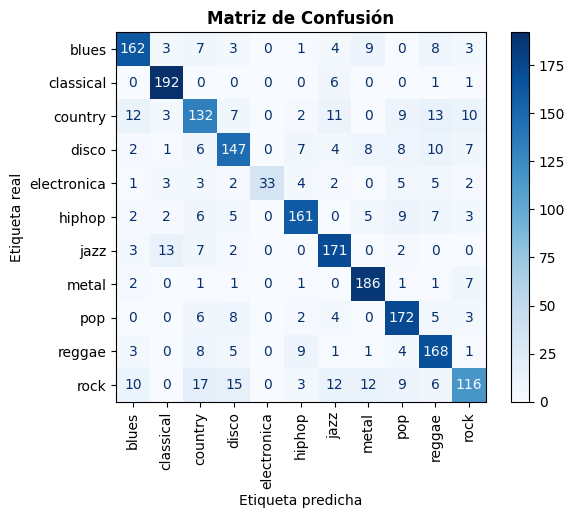

In [61]:
cm = confusion_matrix(y_true=y_test, y_pred=y_pred, labels=model.classes_)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=le.classes_,
)
disp.plot(cmap='Blues', xticks_rotation='vertical')

disp.ax_.set_title("Matriz de Confusión", weight='bold')
disp.ax_.set_xlabel("Etiqueta predicha")
disp.ax_.set_ylabel("Etiqueta real")
plt.show()

# Guardar el modelo en formato joblib

In [62]:
partes = {
    "modelo": model,
    "encoder": le
}

joblib.dump(partes, "modelo.joblib")

['modelo.joblib']

# Guardar modelo en Drive

In [94]:
from google.colab import drive
drive.mount("/content/drive")
!cp /content/modelo.joblib /content/drive/MyDrive

Mounted at /content/drive


# Cargar modelo guardado en formato joblib

In [63]:
modelo_guardado = joblib.load("modelo.joblib")

modelo_g = modelo_guardado["modelo"]
modelo_g.verbose = False
encoder_g = modelo_guardado["encoder"]

# Probar con alguna canción y el modelo guardado

In [ ]:
y_p, sr_p = librosa.load("/content/01. The Girl Who Fell From the Sky.mp3", duration=3)

prueba = extraer_caracteristicas(y_block=y_p, sr=sr_p)

pred = modelo_g.predict([prueba])[0]

genre = encoder_g.inverse_transform([pred])[0]
print(f"La canción se clasificó como: {genre}")

La canción se clasificó como: classical


In [ ]:
y_p, sr_p = librosa.load("/content/53 - The Weeknd - The Hills.mp3", duration=3, offset=30) # Bad, The time

prueba = extraer_caracteristicas(y_block=y_p, sr=sr_p)

pred = modelo_g.predict([prueba])[0]

genre = encoder_g.inverse_transform([pred])[0]
print(f"La canción se clasificó como: {genre}")

La canción se clasificó como: electronica


In [ ]:
y_p, sr_p = librosa.load("/content/06 - Black Eyed Peas - The Time (Dirty Bit).mp3", duration=3, offset=30) # Bad, The time

prueba = extraer_caracteristicas(y_block=y_p, sr=sr_p)

pred = modelo_g.predict([prueba])[0]

genre = encoder_g.inverse_transform([pred])[0]
print(f"La canción se clasificó como: {genre}")

La canción se clasificó como: electronica
